In [12]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

dataset =pd.read_csv("OneDrive/Desktop/Summer_2026_works/1Stop/diabetes.csv")
print("hey")


hey


In [13]:
print(dataset)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                  

In [14]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [16]:
dataset.isnull()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
763,False,False,False,False,False,False,False,False,False
764,False,False,False,False,False,False,False,False,False
765,False,False,False,False,False,False,False,False,False
766,False,False,False,False,False,False,False,False,False


In [17]:
dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


As seen from above the min is coming 0 in almost all columns which is not a valid input so we will be changing these cells with mean or median.

At 50 % that is the median we can compare the mean and see are they in similar range or varies.
If they vary by a lot we know that they are many outliers in the data. Like mean and median of insulin shows the mean to be very high shows either there are a lot of outlier or maybe their many lower values are missing.

In [19]:
features = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
dataset["Insulin"].value_counts()

Insulin
0      374
105     11
130      9
140      9
120      8
      ... 
73       1
171      1
255      1
52       1
112      1
Name: count, Length: 186, dtype: int64

In [21]:
for feature in features:
    print(f"{feature} has {(dataset[feature]==0).mean()*100:.2f}% invalid data")

Glucose has 0.65% invalid data
BloodPressure has 4.56% invalid data
SkinThickness has 29.56% invalid data
Insulin has 48.70% invalid data
BMI has 1.43% invalid data


In [23]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


Text(0.5, 1.0, 'Correlation heatmap')

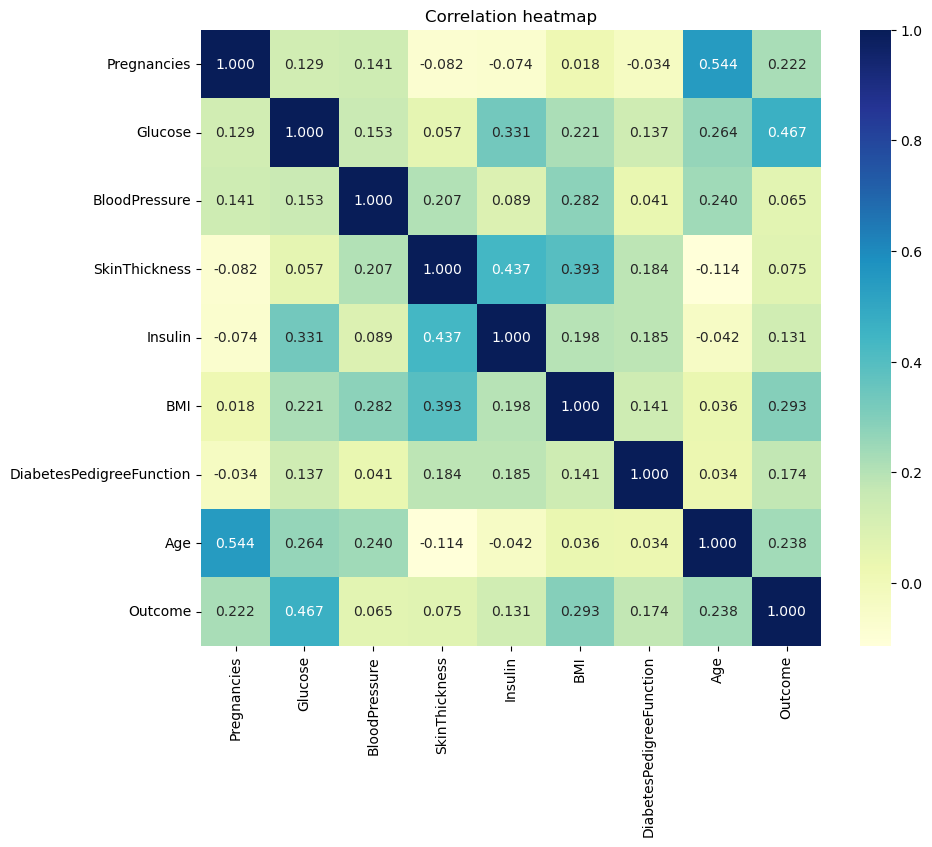

In [32]:
# Correlation plot of invariable variables
plt.figure(figsize=(10,8))
sns.heatmap(dataset.corr(),annot=True,fmt=".3f",cmap="YlGnBu")
plt.title("Correlation heatmap")

Exploring pregnancy and target variables and plotting density function graphs of pregnancy and target variables

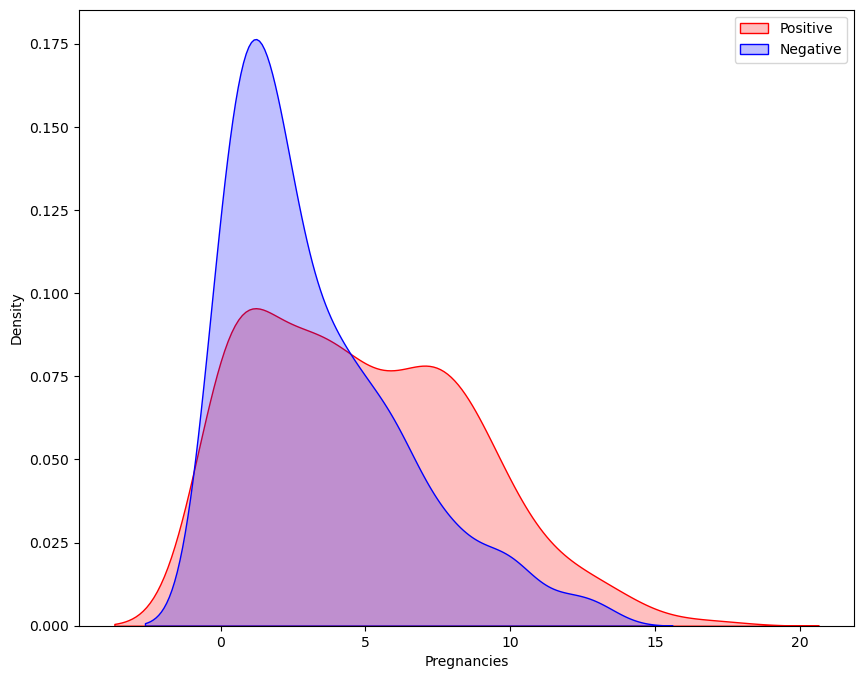

In [40]:
plt.figure(figsize=(10,8))
kde= sns.kdeplot(dataset["Pregnancies"][dataset["Outcome"]==1], color="Red",fill=True)
kde=sns.kdeplot(dataset["Pregnancies"][dataset["Outcome"]==0],color="Blue",fill=True)
kde.set_xlabel("Pregnancies")
kde.set_ylabel("Density")
kde.legend(["Positive","Negative"])

Exploring Glucose and target variables

<Axes: xlabel='Outcome', ylabel='Glucose'>

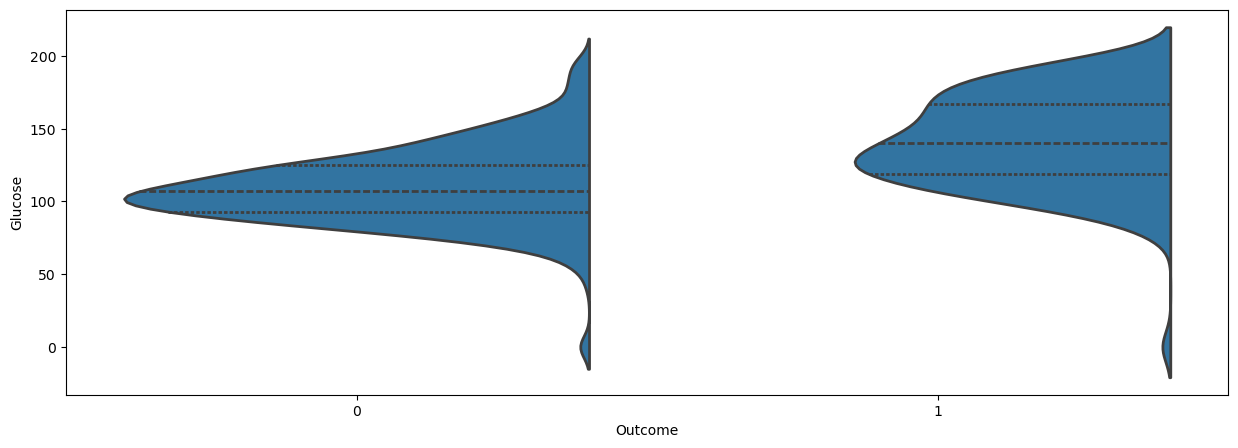

In [58]:
plt.figure(figsize=(15,5))
sns.violinplot(data=dataset,y="Glucose",x="Outcome",split=True,linewidth=2,inner="quart")

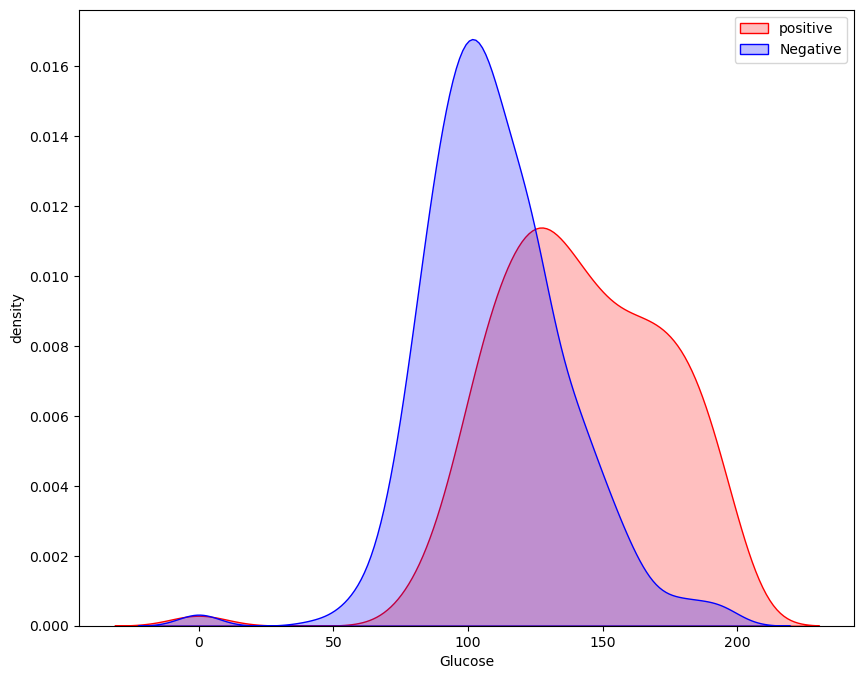

In [45]:
plt.figure(figsize=(10,8))
gde=sns.kdeplot(dataset["Glucose"][dataset["Outcome"]==1],color="Red",fill=True)
gde=sns.kdeplot(dataset["Glucose"][dataset["Outcome"]==0],color="Blue",fill=True)
gde.set_xlabel("Glucose")
gde.set_ylabel("density")
gde.legend(["positive","Negative"])

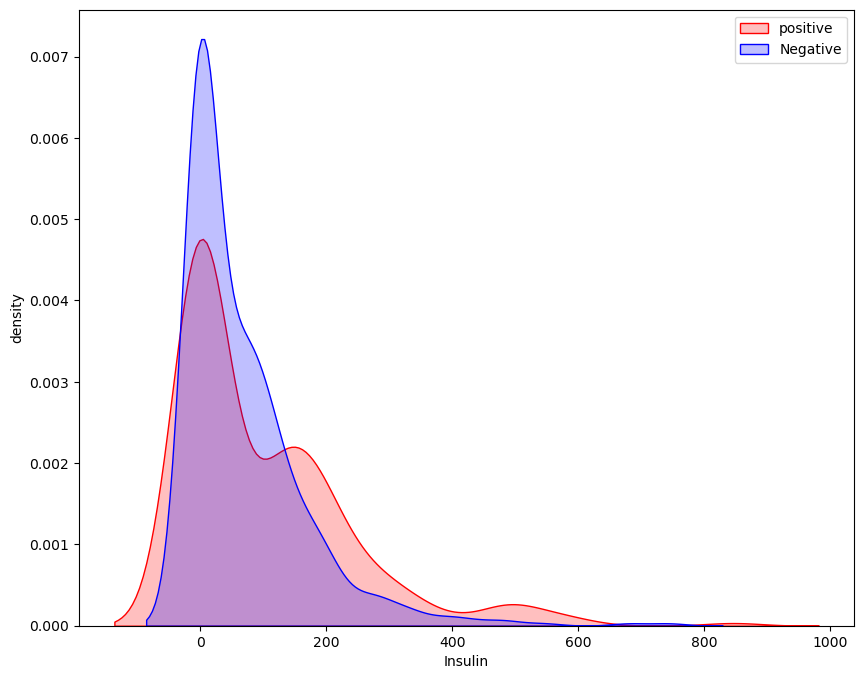

In [46]:
plt.figure(figsize=(10,8))
gde=sns.kdeplot(dataset["Insulin"][dataset["Outcome"]==1],color="Red",fill=True)
gde=sns.kdeplot(dataset["Insulin"][dataset["Outcome"]==0],color="Blue",fill=True)
gde.set_xlabel("Insulin")
gde.set_ylabel("density")
gde.legend(["positive","Negative"])

Replace 0 with the mean/median of the its respective mean/median.

In [64]:
for feature in ["Glucose","BloodPressure"]:
    dataset[feature]=dataset[feature].replace(0,dataset[feature].median())
for feature in ["BMI","SkinThickness","Insulin"]:
    dataset[feature]=dataset[feature].replace(0,dataset[feature].mean())    
dataset["Insulin"]

0       79.799479
1       79.799479
2       79.799479
3       94.000000
4      168.000000
          ...    
763    180.000000
764     79.799479
765    112.000000
766     79.799479
767     79.799479
Name: Insulin, Length: 768, dtype: float64

# Splitting the dependent and independent variable.

In [85]:
X=dataset.drop(["Outcome"],axis=1)
y=dataset["Outcome"]
X
y

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64

# Splitting the dataset into training and testing dataset

In [81]:
from sklearn.model_selection import train_test_split

In [127]:
 X_train, X_test, y_train, y_test = train_test_split(  X, y, test_size=0.33, random_state=5)

# KNN 

In [128]:

from sklearn.neighbors import KNeighborsClassifier 

In [129]:
training_accuracy=[]
test_accuracy=[]
for n_neighbors in range(1,11):
    knn=KNeighborsClassifier (n_neighbors=n_neighbors)
    knn.fit(X_train, y_train)
    training_accuracy.append(knn.score(X_train,y_train))
    test_accuracy.append(knn.score(X_test,y_test))
    

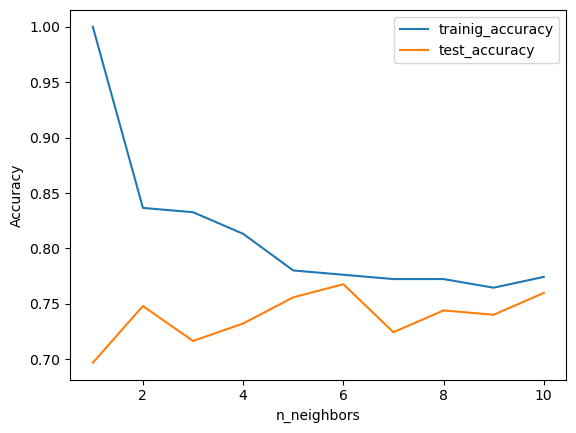

In [130]:
plt.plot(range(1,11),training_accuracy,label="trainig_accuracy")
plt.plot(range(1,11),test_accuracy,label="test_accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()

In [134]:
knn=KNeighborsClassifier(n_neighbors=6)
knn.fit(X_train,y_train)
print("Training accuracy: ",knn.score(X_train,y_train))
print("Test accuracy: ",knn.score(X_test,y_test))


Training accuracy:  0.7762645914396887
Test accuracy:  0.7677165354330708


In [166]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(random_state=1)
dt.fit(X_train,y_train)
print("Training accuracy: ",dt.score(X_train,y_train))
print("Test accuracy: ",dt.score(X_test,y_test))

Training accuracy:  1.0
Test accuracy:  0.6811023622047244


In [164]:
from sklearn.tree import DecisionTreeClassifier
dt1=DecisionTreeClassifier(random_state=1,max_depth=3)
dt1.fit(X_train,y_train)
print("Training accuracy: ",dt1.score(X_train,y_train))
print("Test accuracy: ",dt1.score(X_test,y_test))

Training accuracy:  0.7762645914396887
Test accuracy:  0.7795275590551181


In [175]:
from sklearn.neural_network import MLPClassifier
mlp=DecisionTreeClassifier(random_state=15)
mlp.fit(X_train,y_train)
print("Training accuracy: ",mlp.score(X_train,y_train))
print("Test accuracy: ",mlp.score(X_test,y_test))

Training accuracy:  1.0
Test accuracy:  0.6811023622047244


In [181]:
## Scaling the inputs so each feature will have equal weightage.

In [170]:
from sklearn.preprocessing import StandardScaler
sc= StandardScaler()
X_train_scaled=sc.fit_transform(X_train)
X_test_scaled=sc.fit_transform(X_test)

In [179]:

mlp1=DecisionTreeClassifier(random_state=15)
mlp1.fit(X_train_scaled,y_train)
print("Training accuracy: ",mlp1.score(X_train_scaled,y_train))
print("Test accuracy: ",mlp1.score(X_test_scaled,y_test))

Training accuracy:  1.0
Test accuracy:  0.7125984251968503


The end.